## NB03 Analysis

In [435]:
import pandas as pd 
import os
from pathlib import Path
import sqlite3

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import re
import plotly.graph_objects as go

from numpy.polynomial.polynomial import Polynomial
import numpy as np

import plotly.express as px

# Visualise the distribution of comments per post
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from datetime import datetime
from sqlalchemy import create_engine, text

# Import our custom Reddit API module

# --- Configuration for Jupyter ---
# The following magic command is for Jupyter notebooks to render plots inline.
# It should be commented out when running as a standalone script.
%config InlineBackend.figure_formats = ['svg']


In [412]:
engine = create_engine("sqlite:///../data/fantasy_data.db")

**Objective:**
The goal of this section is to determine which drafted players in my league provided the most value in fantasy football by calculating Value Over Replacement Player (VORP). This metric estimates how many more points a player scored compared to a “replacement-level” player at the same position.


**Methodology:**

**Identify Replacement-Level Benchmarks:**

For each position, I calculated the average points per game (PPG) of players near the end of a 14-team league’s starting range. This simulates a “freely available” player.

**Replacement-level ranges:**

QB: Positional ranks 15–18

RB: Ranks 29–32

WR: Ranks 29–32 (including lineupSlotId 4 and 23 for FLEX)

TE: Ranks 15–16

K / DST: Ranks 15–18

**Account for Lineup Slot Variations:**

Some players are listed under different lineupSlotIds depending on their team’s roster setup.

For example, QBs appeared with both slot ID 0 and 20 — both were included in the QB replacement calculation and VORP logic.

**Calculate VORP:**

For each drafted player, I subtracted the replacement-level PPG for their position from their actual PPG.

Players not in a valid draft slot or without enough data received NULL VORP.



In [413]:
## RB = 2, WR = 4, WR = 23, QB = 20, TE = 6, K =17, D/ST = 16
def calculate_all_vorp(engine):
    query = """
    WITH qb_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players 
        WHERE (lineupSlotId = 20 OR lineupSlotId = 0) AND posRank BETWEEN 15 AND 18
    ),
    rb_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players 
        WHERE lineupSlotId = 2 AND posRank BETWEEN 29 AND 32
    ),
    wr_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players 
        WHERE (lineupSlotId = 4 OR lineupSlotId = 23) AND posRank BETWEEN 29 AND 32
    ),
    te_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players 
        WHERE lineupSlotId = 6 AND posRank BETWEEN 15 AND 16
    ),
    k_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players 
        WHERE lineupSlotId = 17 AND posRank BETWEEN 15 AND 18
    ),
    dst_replacement AS (
        SELECT AVG(points) AS ppg 
        FROM players 
        WHERE lineupSlotId = 16 AND posRank BETWEEN 15 AND 18
    )

    SELECT 
        d.player_id,
        p.player_name,
        p.points,
        p.games_played,
        t.team_name,
        d.position,
        p.avg_points,
        p.projected_points,
        (p.points - p.projected_points) AS boom_bust,
        d.lineupSlotId,
        d.roundPickNumber,
        d.overallPickNumber,
        a.avg,
        (d.overallPickNumber - a.avg) AS draft_delta,
        d.roundId,
        ROUND(
            CASE 
                WHEN d.lineupSlotId IN (0,20) THEN p.points - ((SELECT ppg FROM qb_replacement))
                WHEN d.lineupSlotId = 2 THEN p.points - ((SELECT ppg FROM rb_replacement))
                WHEN d.lineupSlotId IN (4,23) THEN p.points - ((SELECT ppg FROM wr_replacement))
                WHEN d.lineupSlotId = 6 THEN p.points - ((SELECT ppg FROM te_replacement))
                WHEN d.lineupSlotId = 17 THEN p.points - ((SELECT ppg FROM k_replacement))
                WHEN d.lineupSlotId = 16 THEN p.points - ((SELECT ppg FROM dst_replacement))
                ELSE NULL
            END
        , 2) AS vorp
    FROM draft d
    JOIN players p ON d.player_id = p.player_id
    JOIN teams t ON d.team_id = t.team_id
    JOIN average_draft_position a ON d.player_id = a.player_id
    WHERE p.points IS NOT NULL
    ORDER BY vorp DESC
    """
    
    
    return pd.read_sql(query, engine)


In [414]:
heatmap_df = calculate_all_vorp(engine)
heatmap_df.head(10)

,player_id,player_name,points,games_played,team_name,position,avg_points,projected_points,boom_bust,lineupSlotId,roundPickNumber,overallPickNumber,avg,draft_delta,roundId,vorp
0,4362628,Ja'Marr Chase,394,17.0,Jean Machine,WR,23.18,288.11,105.89,4,11,11,7.0,4.0,1,288.63
1,3916387,Lamar Jackson,414,17.0,Joemomma,QB,24.35,302.33,111.67,0,10,10,34.3,-24.3,1,250.96
2,4429795,Jahmyr Gibbs,348,17.0,The Ralph Dudes,RB,20.47,237.89,110.11,2,1,15,12.7,2.3,2,242.63
3,3929630,Saquon Barkley,341,16.0,Stretchy Pups Elite,RB,21.31,251.98,89.02,2,3,3,9.0,-6.0,1,235.63
4,4430807,Bijan Robinson,327,17.0,Husky Express,RB,19.24,292.24,34.76,2,7,7,4.3,2.7,1,221.63
5,3043078,Derrick Henry,323,17.0,Mendes Army,RB,19.00,224.16,98.84,2,2,16,17.7,-1.7,2,217.63
6,4374302,Amon-Ra St. Brown,310,17.0,Team Sprawl n Brawl,WR,18.24,282.70,27.30,4,12,12,6.7,5.3,1,204.63
7,4262921,Justin Jefferson,309,17.0,Mendes Army,WR,18.18,281.30,27.70,4,13,13,7.3,5.7,1,203.63
8,3918298,Josh Allen,364,17.0,Mission Viejo Goat,QB,21.41,312.90,51.10,0,4,4,21.7,-17.7,1,200.96
9,3915511,Joe Burrow,360,17.0,Ambler Thighs,QB,21.18,277.46,82.54,0,9,23,56.7,-33.7,2,196.96


In [415]:
heatmap_df.groupby('position')['vorp'].mean().sort_values(ascending=False)

position
RB      95.485714
WR      80.152143
TE     -17.071429
QB     -25.236262
K      -32.540000
D/ST   -69.468571
Name: vorp, dtype: float64

In [416]:
N = {
    'QB': 14,
    'RB': 28,
    'WR': 28,
    'TE': 14,
    'K': 14,
    'D/ST': 14
}
# Filter to top N players per position (e.g., top 12 QBs, 24 RBs, etc.)
# Filter to top N players per position (e.g., top 12 QBs, 24 RBs, etc.)
top_players = (
    heatmap_df.groupby('position')
    .apply(lambda x: x.nlargest(N[x.name], 'vorp'))
    .reset_index(drop=True)  # <-- removes the hierarchical index
)

total_vorp_by_position = (
    top_players.groupby('position')['vorp']
    .sum()
    .sort_values(ascending=False)
)
total_vorp_by_position

/var/folders/z9/9ssv5sps079cjvmsgkqm93w00000gn/T/ipykernel_52738/1994397897.py:13: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



position
WR      3390.64
RB      2673.60
QB      2060.44
TE      -239.00
K       -455.56
D/ST    -972.56
Name: vorp, dtype: float64

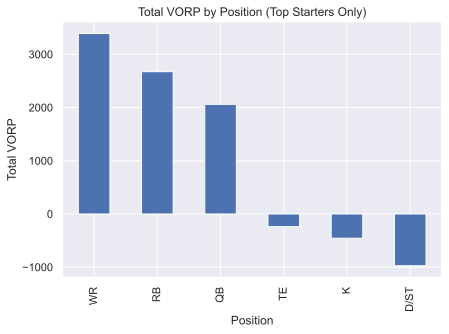

In [417]:
import matplotlib.pyplot as plt

total_vorp_by_position.plot(kind='bar', title='Total VORP by Position (Top Starters Only)')
plt.ylabel('Total VORP')
plt.xlabel('Position')
plt.tight_layout()
plt.show()


In [418]:
position_vorp_dict = total_vorp_by_position.to_dict()
position_vorp_dict


{'WR': 3390.64,
 'RB': 2673.6,
 'QB': 2060.44,
 'TE': -239.0,
 'K': -455.56,
 'D/ST': -972.5600000000001}

In [419]:
max_vorp = max(total_vorp_by_position)
pos_weights = {pos: max(v, 0) / max_vorp for pos, v in total_vorp_by_position.items()}
pos_weights

{'WR': 1.0,
 'RB': 0.788523700540311,
 'QB': 0.6076846848972466,
 'TE': 0.0,
 'K': 0.0,
 'D/ST': 0.0}

In [420]:
query = """
SELECT 
    p.player_id,
    p.player_name,
    a.avg,
    d.overallPickNumber,
    (((d.overallPickNumber - a.avg)/a.avg)) AS draft_discount
FROM draft d
JOIN players p ON d.player_id = p.player_id
JOIN average_draft_position a ON d.player_id = a.player_id
ORDER BY draft_discount DESC
"""

draft_discount = pd.read_sql(query, engine)
draft_discount

,player_id,player_name,avg,overallPickNumber,draft_discount
0,3116406,Tyreek Hill,3.3,6,0.818182
1,4374302,Amon-Ra St. Brown,6.7,12,0.791045
2,4262921,Justin Jefferson,7.3,13,0.780822
3,4242335,Jonathan Taylor,10.0,17,0.700000
4,4430807,Bijan Robinson,4.3,7,0.627907
...,...,...,...,...,...
214,8439,Aaron Rodgers,128.0,47,-0.632812
215,3121023,Dallas Goedert,107.7,38,-0.647168
216,3929630,Saquon Barkley,9.0,3,-0.666667
217,3916387,Lamar Jackson,34.3,10,-0.708455


In [421]:
heatmap_df = heatmap_df.merge(draft_discount[['player_id', 'draft_discount']], on='player_id', how='left')
heatmap_df

,player_id,player_name,points,games_played,team_name,position,avg_points,projected_points,boom_bust,lineupSlotId,roundPickNumber,overallPickNumber,avg,draft_delta,roundId,vorp,draft_discount
0,4362628,Ja'Marr Chase,394,17.0,Jean Machine,WR,23.18,288.11,105.89,4,11,11,7.0,4.0,1,288.63,0.571429
1,3916387,Lamar Jackson,414,17.0,Joemomma,QB,24.35,302.33,111.67,0,10,10,34.3,-24.3,1,250.96,-0.708455
2,4429795,Jahmyr Gibbs,348,17.0,The Ralph Dudes,RB,20.47,237.89,110.11,2,1,15,12.7,2.3,2,242.63,0.181102
3,3929630,Saquon Barkley,341,16.0,Stretchy Pups Elite,RB,21.31,251.98,89.02,2,3,3,9.0,-6.0,1,235.63,-0.666667
4,4430807,Bijan Robinson,327,17.0,Husky Express,RB,19.24,292.24,34.76,2,7,7,4.3,2.7,1,221.63,0.627907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,4690923,Ben Sinnott,12,17.0,Husky Express,QB,0.71,74.06,-62.06,20,7,203,161.0,42.0,15,-151.04,0.260870
215,3924365,Hayden Hurst,12,9.0,Ambler Thighs,QB,1.33,99.38,-87.38,20,9,219,277.0,-58.0,16,-151.04,-0.209386
216,4242214,Clyde Edwards-Helaire,9,NaN,Stretchy Pups Elite,QB,4.50,67.45,-58.45,20,3,199,213.5,-14.5,15,-154.04,-0.067916
217,4596334,Keaton Mitchell,6,5.0,Mendes Army,QB,1.20,46.55,-40.55,20,2,212,246.0,-34.0,16,-157.04,-0.138211


In [422]:
heatmap_df['pos_weight'] = heatmap_df['position'].map(pos_weights)
heatmap_df['value_score'] = heatmap_df['vorp'] * heatmap_df['draft_discount'] * heatmap_df['pos_weight']

min_val = heatmap_df['value_score'].min()
heatmap_df['value_score'] = heatmap_df['value_score'] - min_val


heatmap_df.sort_values(by='value_score', ascending=False)

,player_id,player_name,points,games_played,team_name,position,avg_points,projected_points,boom_bust,lineupSlotId,roundPickNumber,overallPickNumber,avg,draft_delta,roundId,vorp,draft_discount,pos_weight,value_score
0,4362628,Ja'Marr Chase,394,17.0,Jean Machine,WR,23.18,288.11,105.89,4,11,11,7.0,4.0,1,288.63,0.571429,1.000000,288.797988
6,4374302,Amon-Ra St. Brown,310,17.0,Team Sprawl n Brawl,WR,18.24,282.70,27.30,4,12,12,6.7,5.3,1,204.63,0.791045,1.000000,285.738052
7,4262921,Justin Jefferson,309,17.0,Mendes Army,WR,18.18,281.30,27.70,4,13,13,7.3,5.7,1,203.63,0.780822,1.000000,282.865327
4,4430807,Bijan Robinson,327,17.0,Husky Express,RB,19.24,292.24,34.76,2,7,7,4.3,2.7,1,221.63,0.627907,0.788524,233.599902
41,3116406,Tyreek Hill,209,17.0,Ambler Thighs,WR,12.29,297.81,-88.81,4,6,6,3.3,2.7,1,103.63,0.818182,1.000000,208.654742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29,4241463,Jerry Jeudy,233,17.0,South Bay Starr Power,WR,13.71,176.57,56.43,23,1,85,139.3,-54.3,7,127.63,-0.389806,1.000000,74.115598
9,3915511,Joe Burrow,360,17.0,Ambler Thighs,QB,21.18,277.46,82.54,0,9,23,56.7,-33.7,2,196.96,-0.594356,0.607685,52.728311
8,3918298,Josh Allen,364,17.0,Mission Viejo Goat,QB,21.41,312.90,51.10,0,4,4,21.7,-17.7,1,200.96,-0.815668,0.607685,24.256902
1,3916387,Lamar Jackson,414,17.0,Joemomma,QB,24.35,302.33,111.67,0,10,10,34.3,-24.3,1,250.96,-0.708455,0.607685,15.823979


In [423]:
heatmap_df

,player_id,player_name,points,games_played,team_name,position,avg_points,projected_points,boom_bust,lineupSlotId,roundPickNumber,overallPickNumber,avg,draft_delta,roundId,vorp,draft_discount,pos_weight,value_score
0,4362628,Ja'Marr Chase,394,17.0,Jean Machine,WR,23.18,288.11,105.89,4,11,11,7.0,4.0,1,288.63,0.571429,1.000000,288.797988
1,3916387,Lamar Jackson,414,17.0,Joemomma,QB,24.35,302.33,111.67,0,10,10,34.3,-24.3,1,250.96,-0.708455,0.607685,15.823979
2,4429795,Jahmyr Gibbs,348,17.0,The Ralph Dudes,RB,20.47,237.89,110.11,2,1,15,12.7,2.3,2,242.63,0.181102,0.788524,158.514974
3,3929630,Saquon Barkley,341,16.0,Stretchy Pups Elite,RB,21.31,251.98,89.02,2,3,3,9.0,-6.0,1,235.63,-0.666667,0.788524,0.000000
4,4430807,Bijan Robinson,327,17.0,Husky Express,RB,19.24,292.24,34.76,2,7,7,4.3,2.7,1,221.63,0.627907,0.788524,233.599902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,4690923,Ben Sinnott,12,17.0,Husky Express,QB,0.71,74.06,-62.06,20,7,203,161.0,42.0,15,-151.04,0.260870,0.607685,99.922726
215,3924365,Hayden Hurst,12,9.0,Ambler Thighs,QB,1.33,99.38,-87.38,20,9,219,277.0,-58.0,16,-151.04,-0.209386,0.607685,143.085016
216,4242214,Clyde Edwards-Helaire,9,NaN,Stretchy Pups Elite,QB,4.50,67.45,-58.45,20,3,199,213.5,-14.5,15,-154.04,-0.067916,0.607685,130.223995
217,4596334,Keaton Mitchell,6,5.0,Mendes Army,QB,1.20,46.55,-40.55,20,2,212,246.0,-34.0,16,-157.04,-0.138211,0.607685,137.056183


In [424]:
# Add this before pivoting
min_score = heatmap_df['boom_bust'].min()
max_score = heatmap_df['boom_bust'].max()

# Create a normalized column
heatmap_df['boom_bust_normalized'] = (heatmap_df['boom_bust'] - min_score) / (max_score - min_score)

# Then pivot using normalized values
pivot_score = heatmap_df.pivot(index='roundPickNumber', columns='roundId', values='boom_bust_normalized')
heatmap_df

,player_id,player_name,points,games_played,team_name,position,avg_points,projected_points,boom_bust,lineupSlotId,roundPickNumber,overallPickNumber,avg,draft_delta,roundId,vorp,draft_discount,pos_weight,value_score,boom_bust_normalized
0,4362628,Ja'Marr Chase,394,17.0,Jean Machine,WR,23.18,288.11,105.89,4,11,11,7.0,4.0,1,288.63,0.571429,1.000000,288.797988,0.985646
1,3916387,Lamar Jackson,414,17.0,Joemomma,QB,24.35,302.33,111.67,0,10,10,34.3,-24.3,1,250.96,-0.708455,0.607685,15.823979,1.000000
2,4429795,Jahmyr Gibbs,348,17.0,The Ralph Dudes,RB,20.47,237.89,110.11,2,1,15,12.7,2.3,2,242.63,0.181102,0.788524,158.514974,0.996126
3,3929630,Saquon Barkley,341,16.0,Stretchy Pups Elite,RB,21.31,251.98,89.02,2,3,3,9.0,-6.0,1,235.63,-0.666667,0.788524,0.000000,0.943750
4,4430807,Bijan Robinson,327,17.0,Husky Express,RB,19.24,292.24,34.76,2,7,7,4.3,2.7,1,221.63,0.627907,0.788524,233.599902,0.809000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,4690923,Ben Sinnott,12,17.0,Husky Express,QB,0.71,74.06,-62.06,20,7,203,161.0,42.0,15,-151.04,0.260870,0.607685,99.922726,0.568555
215,3924365,Hayden Hurst,12,9.0,Ambler Thighs,QB,1.33,99.38,-87.38,20,9,219,277.0,-58.0,16,-151.04,-0.209386,0.607685,143.085016,0.505675
216,4242214,Clyde Edwards-Helaire,9,NaN,Stretchy Pups Elite,QB,4.50,67.45,-58.45,20,3,199,213.5,-14.5,15,-154.04,-0.067916,0.607685,130.223995,0.577520
217,4596334,Keaton Mitchell,6,5.0,Mendes Army,QB,1.20,46.55,-40.55,20,2,212,246.0,-34.0,16,-157.04,-0.138211,0.607685,137.056183,0.621973


In [425]:
query = """ 
SELECT 
    p.player_name,
    d.position,
    p.points,
    p.avg_points,
    d.overallPickNumber
FROM players p 
JOIN draft d ON p.player_id = d.player_id
"""
pd.read_sql(query, engine)
heatmap_df

,player_id,player_name,points,games_played,team_name,position,avg_points,projected_points,boom_bust,lineupSlotId,roundPickNumber,overallPickNumber,avg,draft_delta,roundId,vorp,draft_discount,pos_weight,value_score,boom_bust_normalized
0,4362628,Ja'Marr Chase,394,17.0,Jean Machine,WR,23.18,288.11,105.89,4,11,11,7.0,4.0,1,288.63,0.571429,1.000000,288.797988,0.985646
1,3916387,Lamar Jackson,414,17.0,Joemomma,QB,24.35,302.33,111.67,0,10,10,34.3,-24.3,1,250.96,-0.708455,0.607685,15.823979,1.000000
2,4429795,Jahmyr Gibbs,348,17.0,The Ralph Dudes,RB,20.47,237.89,110.11,2,1,15,12.7,2.3,2,242.63,0.181102,0.788524,158.514974,0.996126
3,3929630,Saquon Barkley,341,16.0,Stretchy Pups Elite,RB,21.31,251.98,89.02,2,3,3,9.0,-6.0,1,235.63,-0.666667,0.788524,0.000000,0.943750
4,4430807,Bijan Robinson,327,17.0,Husky Express,RB,19.24,292.24,34.76,2,7,7,4.3,2.7,1,221.63,0.627907,0.788524,233.599902,0.809000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,4690923,Ben Sinnott,12,17.0,Husky Express,QB,0.71,74.06,-62.06,20,7,203,161.0,42.0,15,-151.04,0.260870,0.607685,99.922726,0.568555
215,3924365,Hayden Hurst,12,9.0,Ambler Thighs,QB,1.33,99.38,-87.38,20,9,219,277.0,-58.0,16,-151.04,-0.209386,0.607685,143.085016,0.505675
216,4242214,Clyde Edwards-Helaire,9,NaN,Stretchy Pups Elite,QB,4.50,67.45,-58.45,20,3,199,213.5,-14.5,15,-154.04,-0.067916,0.607685,130.223995,0.577520
217,4596334,Keaton Mitchell,6,5.0,Mendes Army,QB,1.20,46.55,-40.55,20,2,212,246.0,-34.0,16,-157.04,-0.138211,0.607685,137.056183,0.621973


## Visualizations

### Creating the Heatmap

In [426]:
pivot_score = heatmap_df.pivot(index='roundPickNumber', columns='roundId', values='vorp')
pivot_player = heatmap_df.pivot(index='roundPickNumber', columns='roundId', values='player_name')
pivot_position = heatmap_df.pivot(index='roundPickNumber', columns='roundId', values='position')
pivot_points = heatmap_df.pivot(index='roundPickNumber', columns='roundId', values='points')
pivot_teams = heatmap_df.pivot(index='roundPickNumber', columns='roundId', values='team_name')


# Build hover text
hover_text = (
    '<b>' + pivot_player.fillna('') + '</b><br>' +
    'Pos: ' + pivot_position.fillna('') + '<br>' +
    'VORP: ' + pivot_score.round(2).astype(str) + '<br>' +
    'Points: ' + pivot_points.fillna(0).astype(int).astype(str) + '<br>' + 
    'Team: ' + pivot_teams.fillna('NA').astype(str)
)

# Create Heatmap
fig = go.Figure(data=go.Heatmap(
    z=pivot_score.values,
    x=pivot_score.columns,
    y=pivot_score.index,
    text=hover_text.values,
    hoverinfo="text",
    colorscale='RdYlGn',
    zmin=pivot_score.min().min(),
    zmax=pivot_score.max().max(),
    showscale=True,
    colorbar=dict(title="VORP"),
))

# Add text in center of each box (VORP)
for i in range(len(pivot_score.index)):
    for j in range(len(pivot_score.columns)):
        value = pivot_score.iloc[i, j]
        if pd.notnull(value):
            fig.add_annotation(
                text=f"{value:.1f}",
                x=pivot_score.columns[j],
                y=pivot_score.index[i],
                showarrow=False,
                font=dict(color="black", size=10),
                xanchor="center",
                yanchor="middle"
            )

# Layout adjustments
fig.update_layout(
    title="VORP",
    xaxis=dict(title="Draft Round", side='top', tickmode='linear', dtick=1),
    yaxis=dict(title="Pick Number in Round", autorange='reversed', tickmode='linear', dtick=1),
    width=1000,
    height=700,
    plot_bgcolor='white'
)

fig.write_html("../docs/charts/draft_value_chart.html")
fig.show()


In [ ]:


df = heatmap_df.copy()
X = df[['overallPickNumber']]  # x-axis: draft pick number
y = df['vorp']            # y-axis: VORP

# Polynomial regression (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model = LinearRegression().fit(X_poly, y)
y_pred = model.predict(X_poly)

# Find x-intercept where curve crosses y=0
a, b, c = model.coef_[2], model.coef_[1], model.intercept_
discriminant = b**2 - 4*a*c
x0 = (-b + np.sqrt(discriminant)) / (2*a)

# Translate to round/pick (assume 14 teams)
teams = 14
round_num = int(x0 // teams) + 1
pick_in_round = int(x0 % teams) + 1
label = f"Round {round_num}, Pick {pick_in_round}"

# Plot
plt.figure(figsize=(14, 6))
plt.scatter(X, y, alpha=0.6, color='green')
plt.plot(X, y_pred, color='black', linewidth=2)

# Bold horizontal line at y=0
plt.axhline(0, color='black', linewidth=2)

# Vertical dashed line at x-intercept
plt.axvline(x0, color='red', linestyle='--', linewidth=2)

# Annotate intersection
plt.text(x0, -100, label, ha='center', va='center', color='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3'))

# Optional: draw round backgrounds + labels
max_pick = df['overall_pick'].max()
num_rounds = int(np.ceil(max_pick / teams))
for i in range(num_rounds):
    left = i * teams
    right = left + teams
    plt.axvspan(left, right, color='lightgrey', alpha=0.2)
    plt.text((left + right) / 2, -60, f'R{i+1}', ha='center', fontsize=10)

# Labels & title
plt.xlabel("Draft Pick")
plt.ylabel("VORP")
plt.title("Draft Pick vs. Value Over Replacement (VORP)")
plt.tight_layout()
plt.show()

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [428]:
heatmap_df[heatmap_df['games_played'].isna()]

,player_id,player_name,points,games_played,team_name,position,avg_points,projected_points,boom_bust,lineupSlotId,roundPickNumber,overallPickNumber,avg,draft_delta,roundId,vorp,draft_discount,pos_weight,value_score,boom_bust_normalized
148,4361529,Isiah Pacheco,52,NaN,Deb’s Debsters,RB,7.43,231.64,-179.64,2,8,8,21.0,-13.0,1,-53.38,-0.619048,0.788524,149.923138,0.276554
192,4428331,Rashee Rice,64,NaN,Luke's Cool Guys,QB,16.00,208.43,-144.43,20,13,83,66.3,16.7,6,-99.04,0.251885,0.607685,108.706816,0.363995
193,4678008,Jonathon Brooks,6,NaN,Team Sprawl n Brawl,RB,2.00,138.94,-132.94,2,12,68,108.7,-40.7,5,-99.38,-0.374425,0.788524,153.207810,0.392530
216,4242214,Clyde Edwards-Helaire,9,NaN,Stretchy Pups Elite,QB,4.50,67.45,-58.45,20,3,199,213.5,-14.5,15,-154.04,-0.067916,0.607685,130.223995,0.577520
218,4429023,MarShawn Lloyd,2,NaN,Luke's Cool Guys,QB,2.00,74.58,-72.58,20,13,167,169.0,-2.0,12,-161.04,-0.011834,0.607685,125.024684,0.542429


Focus on who was the best value in the fantasy league

Who had the most value per ppg